# InvertibleNet: 反復的反実仮想推論

このノートブックは既存の `semi_supervised_cifar10_simclr.ipynb` の **InvertibleNetCIFAR** を再利用し、Track 2 を置き換える実験です。

各候補クラス $c$ について、分類ヘッド $W$ の転置を使い、潜在表現を反復更新します。

更新式: z[t+1,c] = z[t,c] + alpha × m × normalize(W^T (onehot(c) - softmax(W z[t,c] + b))).\n
これはクラス $c$ への交差エントロピーを下げる特徴空間での勾配方向を、**分類ヘッドと重み共有して**用いるものです。各 $z_t^{(c)}$ は既存の厳密な逆写像 $f^{-1}$ で画像化できます。候補の評価は、目標クラスのロジットから、元画像との固定特徴距離と潜在移動量を引いた値で行います。

従来 Track 2 の『クラス平均画像／平均特徴への接近』を使わないため、元画像の背景・色・姿勢などを保存したまま、クラスに必要な成分だけを動かすことを狙います。

Device: cuda
n_labeled=50  n_unlabeled=100  seed=42
HuggingFace から CIFAR-10 をロード...


train: torch.Size([50000, 3, 32, 32])  test: torch.Size([10000, 3, 32, 32])
labeled_train=40  val=10  unlabeled=100
(test=10000  CLIP zero-shot参考値=92.93%, 比較しない)
CV folds: k=5 (n_per_class_labeled=5, cfg.n_cv_folds=5)
  fold 0: train=40  val=10
  fold 1: train=40  val=10
  fold 2: train=40  val=10
  fold 3: train=40  val=10
  fold 4: train=40  val=10
正規化統計 mean=['0.4914', '0.4822', '0.4465']  std=['0.2470', '0.2435', '0.2616']
  [注意] n_unlabeled=100 < simclr_batch=256 のため batch_size を 100 に自動縮小 (drop_last=Trueだとバッチ0件になりZeroDivisionErrorになるため)
DataLoader 準備完了
重み共有型invert用ヘルパー関数 定義完了
ResNet-18: feat=torch.Size([2, 512])  params=11.17M
ViT-tiny:  feat=torch.Size([2, 192])   params=4.03M
ResNet-18 invert(): torch.Size([2, 3, 32, 32]) (期待値: torch.Size([2, 3, 32, 32]))
ViT-tiny  invert(): torch.Size([2, 3, 32, 32])  (期待値: torch.Size([2, 3, 32, 32]))
InvertibleNetCIFAR: feat_dim=3072  params=0.13M  再構成誤差=7.15e-07 (0に近いほど正しい)
SimCLR 関数定義完了
NN逆関数伝播(Track1/Track2 + データ拡張)関数定義完了
SimCLR用augmentati

semi_supervised_cifar10_simclr.ipynb:cell-12:57: UserWarning: Glyph 20803 (\N{CJK UNIFIED IDEOGRAPH-5143}) missing from font(s) DejaVu Sans.
semi_supervised_cifar10_simclr.ipynb:cell-12:57: UserWarning: Glyph 30011 (\N{CJK UNIFIED IDEOGRAPH-753B}) missing from font(s) DejaVu Sans.
semi_supervised_cifar10_simclr.ipynb:cell-12:57: UserWarning: Glyph 20687 (\N{CJK UNIFIED IDEOGRAPH-50CF}) missing from font(s) DejaVu Sans.
semi_supervised_cifar10_simclr.ipynb:cell-12:57: UserWarning: Glyph 12469 (\N{KATAKANA LETTER SA}) missing from font(s) DejaVu Sans.
semi_supervised_cifar10_simclr.ipynb:cell-12:57: UserWarning: Glyph 12531 (\N{KATAKANA LETTER N}) missing from font(s) DejaVu Sans.
semi_supervised_cifar10_simclr.ipynb:cell-12:57: UserWarning: Glyph 12503 (\N{KATAKANA LETTER PU}) missing from font(s) DejaVu Sans.
semi_supervised_cifar10_simclr.ipynb:cell-12:57: UserWarning: Glyph 12523 (\N{KATAKANA LETTER RU}) missing from font(s) DejaVu Sans.
semi_supervised_cifar10_simclr.ipynb:cell-12:5

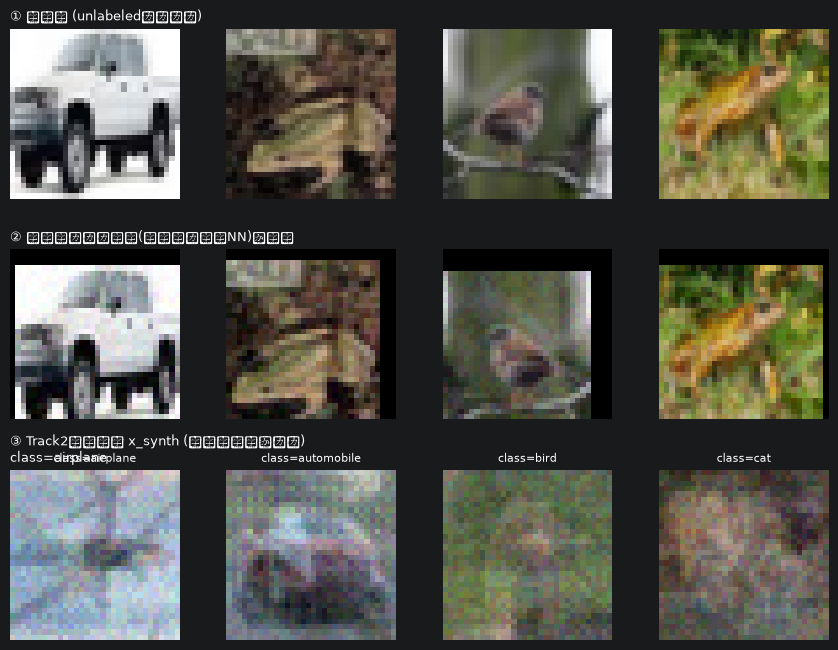

※ ③は未学習(ランダム初期化)モデルでのデモ表示です。実際の学習後の姿を見たい場合は、学習済みbackbone/headに差し替えて同じコードを実行してください。
ApproxDecoder(ResNet/ViT用の学習可能な近似逆写像)定義完了
分類器学習関数定義完了
疑似ラベル自己訓練関数定義完了
Mixup/CutMix関数定義完了
キャッシュユーティリティ定義完了
SAMME boosting (テストセット不使用・キャッシュ対応版) 定義完了
weighted_finetune_with_track2 (二経路勾配降下) 定義完了
loaded definitions; labeled= 40 val= 10 unlabeled= 100


In [1]:
# 元ノートブックの定義セルだけを読み込む（メイン実験セルは実行しない）。
# パスが異なる場合だけ SOURCE_NOTEBOOK を変更してください。
from pathlib import Path
import nbformat

SOURCE_NOTEBOOK = Path(r'D:/Documents/programs/PycharmProjects/risuu/semi_supervised_cifar10_simclr.ipynb')
assert SOURCE_NOTEBOOK.exists(), f'元ノートブックが見つかりません: {SOURCE_NOTEBOOK}'
source_nb = nbformat.read(SOURCE_NOTEBOOK, as_version=4)
for i, cell in enumerate(source_nb.cells[:20]):
    if cell.cell_type == 'code':
        exec(compile(cell.source, f'{SOURCE_NOTEBOOK.name}:cell-{i}', 'exec'), globals())

# 本ノートブックは InvertibleNet のみを使い、元の平均プロトタイプ Track 2 は使わない。
assert cfg.n_labeled == 50 and cfg.n_unlabeled == 100
print('loaded definitions; labeled=', len(train_only_idx), 'val=', len(val_idx), 'unlabeled=', len(unlabeled_idx))

In [2]:
from dataclasses import dataclass

@dataclass
class RecurrentCFConfig:
    steps: int = 3
    epochs: int = 200
    lr: float = 1e-3
    wd: float = 1e-4
    batch: int = 16
    lambda_initial_ce: float = 0.25
    lambda_path_ce: float = 0.35
    lambda_preserve: float = 1.0
    lambda_unlabeled: float = 0.5
    score_feature_penalty: float = 1.0
    score_latent_penalty: float = 0.03

rcfg = RecurrentCFConfig()
set_seed(cfg.seed)
print(rcfg)

RecurrentCFConfig(steps=3, epochs=200, lr=0.001, wd=0.0001, batch=16, lambda_initial_ce=0.25, lambda_path_ce=0.35, lambda_preserve=1.0, lambda_unlabeled=0.5, score_feature_penalty=1.0, score_latent_penalty=0.03)


In [3]:
class TransposeRefiner(nn.Module):
    """全反復で同じ W^T と同じ座標ゲートを用いる潜在更新器。"""
    def __init__(self, feat_dim, n_classes, steps):
        super().__init__()
        self.steps = steps
        self.gate_logits = nn.Parameter(torch.zeros(feat_dim))
        self.log_step = nn.Parameter(torch.tensor(-1.5))

    def step(self, z, target_prob, head):
        p = F.softmax(head(z), dim=-1)
        # d log p(target) / dz。W は分類ヘッドと同一パラメータである。
        direction = (target_prob - p) @ head.weight
        direction = direction / (direction.norm(dim=-1, keepdim=True) + 1e-6)
        gate = torch.sigmoid(self.gate_logits).unsqueeze(0)
        return z + F.softplus(self.log_step) * gate * direction

    def forward(self, z0, target_prob, head):
        zs = []
        z = z0
        for _ in range(self.steps):
            z = self.step(z, target_prob, head)
            zs.append(z)
        return zs

def one_hot(labels):
    return F.one_hot(labels, cfg.n_classes).float()

def all_counterfactuals(backbone, head, refiner, x, feature_net, rcfg):
    """各入力について10クラスの反実仮想軌跡と判定スコアを一括で計算する。"""
    B = x.size(0); K = cfg.n_classes
    z0 = backbone.forward_features(x)
    z0k = z0[:, None, :].expand(B, K, -1).reshape(B*K, -1)
    labels = torch.arange(K, device=x.device).repeat(B)
    target = one_hot(labels)
    zT = refiner(z0k, target, head)[-1]
    xT = backbone.invert(zT)
    base_feat = feature_net(x).flatten(1)
    cf_feat = feature_net(xT).flatten(1).view(B, K, -1)
    feat_dist = (cf_feat - base_feat[:, None, :]).pow(2).mean(dim=-1)
    latent_dist = (zT - z0k).pow(2).mean(dim=-1).view(B, K)
    target_logit = head(zT).gather(1, labels[:, None]).view(B, K)
    scores = target_logit - rcfg.score_feature_penalty * feat_dist - rcfg.score_latent_penalty * latent_dist
    return scores, z0, zT.view(B, K, -1), xT.view(B, K, *x.shape[1:])

class PairedUnlabeled(Dataset):
    def __init__(self, imgs, idx):
        self.imgs = imgs[idx]
    def __len__(self): return len(self.imgs)
    def __getitem__(self, i):
        return eval_aug(self.imgs[i]), train_aug(self.imgs[i])

loader_rec_lbl = make_loader(CIFAR10Set(train_imgs, train_lbls, train_only_idx, train_aug), rcfg.batch)
loader_rec_unl = make_loader(PairedUnlabeled(train_imgs, unlabeled_idx), rcfg.batch)
print('recurrent loaders ready')

recurrent loaders ready


In [4]:
def train_recurrent_counterfactual(rcfg):
    backbone = InvertibleNetCIFAR().to(cfg.device)
    head = nn.Linear(backbone.feat_dim, cfg.n_classes).to(cfg.device)
    refiner = TransposeRefiner(backbone.feat_dim, cfg.n_classes, rcfg.steps).to(cfg.device)
    feature_net = FixedFilterCNN().to(cfg.device).eval()
    for p in feature_net.parameters(): p.requires_grad_(False)
    opt = torch.optim.AdamW(list(backbone.parameters()) + list(head.parameters()) + list(refiner.parameters()),
                            lr=rcfg.lr, weight_decay=rcfg.wd)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, rcfg.epochs)
    unl_iter = iter(loader_rec_unl)
    best = (-float('inf'), None)

    for epoch in tqdm(range(1, rcfg.epochs + 1), desc='recurrent-CF'):
        backbone.train(); head.train(); refiner.train()
        for x, y in loader_rec_lbl:
            x, y = x.to(cfg.device), y.to(cfg.device)
            z0 = backbone.forward_features(x)
            path = refiner(z0, one_hot(y), head)
            xT = backbone.invert(path[-1])
            # 経路の全時点で正しいクラスへ改善させる。
            path_ce = sum(F.cross_entropy(head(z), y) for z in path) / len(path)
            initial_ce = F.cross_entropy(head(z0), y)
            # クラス平均ではなく、入力自身の固定エッジ特徴を保存する。
            with torch.no_grad(): base_feature = feature_net(x)
            preserve = F.mse_loss(feature_net(xT), base_feature)
            # 10候補を競わせ、真のクラスの反実仮想だけを最も自然にする。
            scores, _, _, _ = all_counterfactuals(backbone, head, refiner, x, feature_net, rcfg)
            candidate_ce = F.cross_entropy(scores, y)

            try:
                xw, xs = next(unl_iter)
            except StopIteration:
                unl_iter = iter(loader_rec_unl); xw, xs = next(unl_iter)
            xw, xs = xw.to(cfg.device), xs.to(cfg.device)
            zw = backbone.forward_features(xw)
            pseudo = F.softmax(head(zw), dim=-1).detach()
            zws = refiner(zw, pseudo, head)[-1]
            zss = refiner(backbone.forward_features(xs), pseudo, head)[-1]
            consistency = F.kl_div(F.log_softmax(head(zss), dim=-1),
                                   F.softmax(head(zws), dim=-1).detach(), reduction='batchmean')

            loss = (candidate_ce + rcfg.lambda_initial_ce * initial_ce + rcfg.lambda_path_ce * path_ce
                    + rcfg.lambda_preserve * preserve + rcfg.lambda_unlabeled * consistency)
            opt.zero_grad(); loss.backward(); torch.nn.utils.clip_grad_norm_(
                list(backbone.parameters()) + list(head.parameters()) + list(refiner.parameters()), 5.0)
            opt.step()
        sched.step()

        val_acc = evaluate_recurrent(backbone, head, refiner, feature_net, loader_val, rcfg)[0]
        if val_acc > best[0]:
            best = (val_acc, (copy.deepcopy(backbone.state_dict()), copy.deepcopy(head.state_dict()), copy.deepcopy(refiner.state_dict())))
        if epoch % 20 == 0 or epoch == 1:
            print(f'epoch={epoch:3d}  val={val_acc*100:.1f}%  best={best[0]*100:.1f}%')

    backbone.load_state_dict(best[1][0]); head.load_state_dict(best[1][1]); refiner.load_state_dict(best[1][2])
    return backbone, head, refiner, feature_net, best[0]

@torch.no_grad()
def evaluate_recurrent(backbone, head, refiner, feature_net, loader, rcfg):
    backbone.eval(); head.eval(); refiner.eval(); feature_net.eval()
    correct = total = 0
    for x, y in loader:
        x, y = x.to(cfg.device), y.to(cfg.device)
        scores, _, _, _ = all_counterfactuals(backbone, head, refiner, x, feature_net, rcfg)
        correct += (scores.argmax(1) == y).sum().item(); total += y.numel()
    return correct / total, correct, total

backbone_cf, head_cf, refiner_cf, feature_net_cf, best_val_cf = train_recurrent_counterfactual(rcfg)
print(f'best validation accuracy: {best_val_cf*100:.2f}%')

recurrent-CF:   0%|          | 0/200 [00:00<?, ?it/s]

epoch=  1  val=30.0%  best=30.0%
epoch= 20  val=20.0%  best=30.0%
epoch= 40  val=20.0%  best=30.0%
epoch= 60  val=20.0%  best=30.0%
epoch= 80  val=10.0%  best=40.0%
epoch=100  val=30.0%  best=40.0%
epoch=120  val=30.0%  best=40.0%
epoch=140  val=20.0%  best=40.0%
epoch=160  val=30.0%  best=40.0%
epoch=180  val=20.0%  best=40.0%
epoch=200  val=20.0%  best=40.0%
best validation accuracy: 40.00%


In [5]:
# テストセットはこのセルで一度だけ評価する。ハイパーパラメータ選択には使わない。
test_acc_cf, n_correct, n_total = evaluate_recurrent(
    backbone_cf, head_cf, refiner_cf, feature_net_cf, loader_test, rcfg)
print(f'Recurrent counterfactual InvertibleNet: {test_acc_cf*100:.2f}% ({n_correct}/{n_total})')

# 1 seed の値だけでなく、seedごとにこのノートブックを再実行して平均・標準偏差を報告する。

Recurrent counterfactual InvertibleNet: 22.53% (2253/10000)


In [6]:
# 定性的確認: 予測クラスと2位候補の反実仮想を表示する。
@torch.no_grad()
def show_counterfactuals(n=4):
    import matplotlib.pyplot as plt
    x, y = next(iter(loader_test))
    x, y = x[:n].to(cfg.device), y[:n].to(cfg.device)
    scores, _, _, xcf = all_counterfactuals(backbone_cf, head_cf, refiner_cf, feature_net_cf, x, rcfg)
    top2 = scores.topk(2, dim=1).indices
    mean = torch.tensor(CIFAR10_MEAN, device=x.device).view(1,3,1,1)
    std = torch.tensor(CIFAR10_STD, device=x.device).view(1,3,1,1)
    denorm = lambda q: (q * std + mean).clamp(0, 1).permute(1,2,0).cpu()
    fig, ax = plt.subplots(n, 3, figsize=(8, 2.6*n))
    for i in range(n):
        choices = [None, top2[i,0].item(), top2[i,1].item()]
        titles = [f'input / true={cfg.cifar10_classes[y[i].item()]}',
                  f'candidate 1: {cfg.cifar10_classes[choices[1]]}',
                  f'candidate 2: {cfg.cifar10_classes[choices[2]]}']
        imgs = [x[i], xcf[i, choices[1]], xcf[i, choices[2]]]
        for j in range(3):
            ax[i,j].imshow(denorm(imgs[j])); ax[i,j].set_title(titles[j]); ax[i,j].axis('off')
    plt.tight_layout()

show_counterfactuals()

AttributeError: 'FixedFilterCNN' object has no attribute 'size'